Корень датасета: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset
Исходные размеры:
Train: 140002 изображений
Validation: 39428 изображений
Test: 10905 изображений

После обрезки:
Train: 20000 изображений
Validation: 10000 изображений
Test: 5000 изображений
Train: REAL=10000, FAKE=10000
Validation: REAL=5000, FAKE=5000
Test: REAL=2500, FAKE=2500


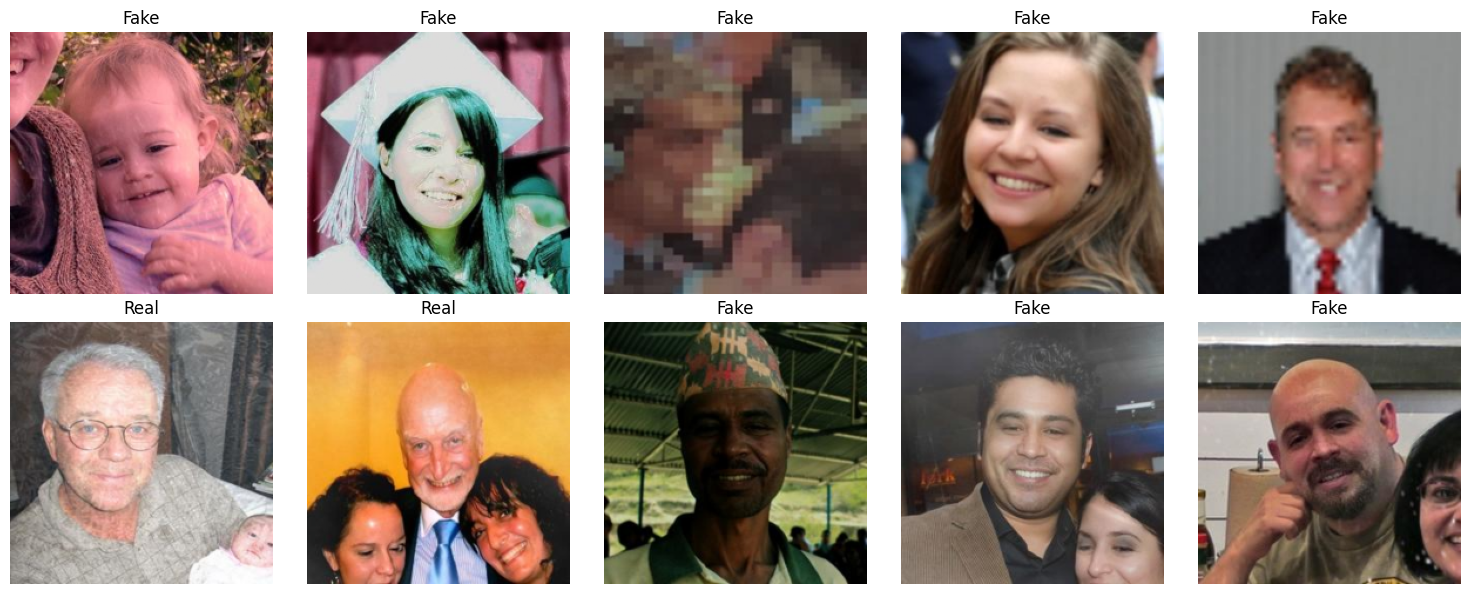

In [10]:
# show_samples.py
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def denormalize(tensor, mean=MEAN, std=STD):
    tensor = tensor.clone().cpu()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    img = tensor.permute(1, 2, 0).clamp(0, 1).numpy()
    return img

def show_random_samples(dataset, num_samples=10, cols=5, figsize=(15, 6)):
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if num_samples > 1 else [axes]

    indices = random.sample(range(len(dataset)), num_samples)
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        img_np = denormalize(img)
        ax.imshow(img_np)
        ax.set_title("Real" if label == 0 else "Fake", fontsize=12)
        ax.axis('off')

    for ax in axes[num_samples:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    _, _, test_dataset = load_data()
    show_random_samples(test_dataset, num_samples=10, cols=5)

Загрузка датасета...
Корень датасета: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset
Исходные размеры:
Train: 140002 изображений
Validation: 39428 изображений
Test: 10905 изображений

После обрезки:
Train: 20000 изображений
Validation: 10000 изображений
Test: 5000 изображений
Train: REAL=10000, FAKE=10000
Validation: REAL=5000, FAKE=5000
Test: REAL=2500, FAKE=2500

Создание модели...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 



Начало обучения...

Epoch 1/10


Validation: 100%|██████████| 79/79 [01:10<00:00,  1.12it/s]


Train Loss: 0.2446, Train Acc: 0.8923
Val Loss: 0.2151, Val Acc: 0.9203

Epoch 2/10


...

Train Loss: 0.0292, Train Acc: 0.9888
Val Loss: 0.1402, Val Acc: 0.9578

Epoch 9/10


Validation: 100%|██████████| 79/79 [00:22<00:00,  3.58it/s]


Train Loss: 0.0234, Train Acc: 0.9922
Val Loss: 0.1416, Val Acc: 0.9592

Epoch 10/10


Validation: 100%|██████████| 79/79 [00:22<00:00,  3.52it/s]


Train Loss: 0.0180, Train Acc: 0.9936
Val Loss: 0.1590, Val Acc: 0.9606

Модель сохранена в models/best_model_weights.pth
Конфигурация сохранена в models/config.json


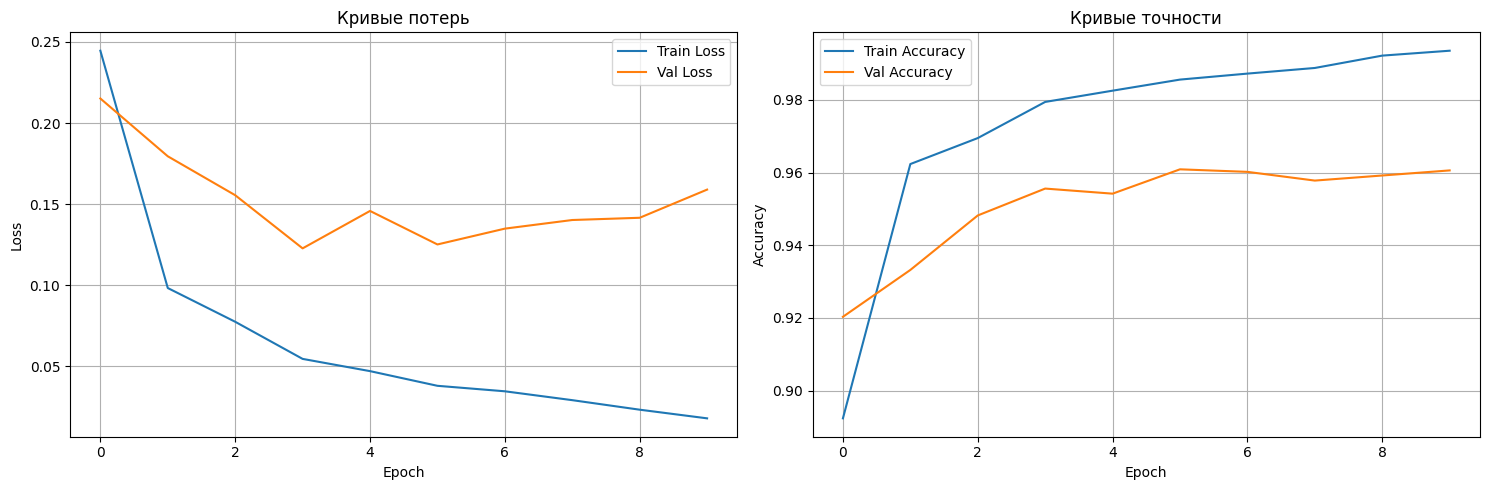


Оценка на тестовом наборе:


Validation: 100%|██████████| 40/40 [00:28<00:00,  1.41it/s]


Тестовая точность: 0.8826
Тестовые потери: 0.4757

Classification Report:
              precision    recall  f1-score   support

        REAL       0.93      0.83      0.88      2500
        FAKE       0.85      0.94      0.89      2500

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



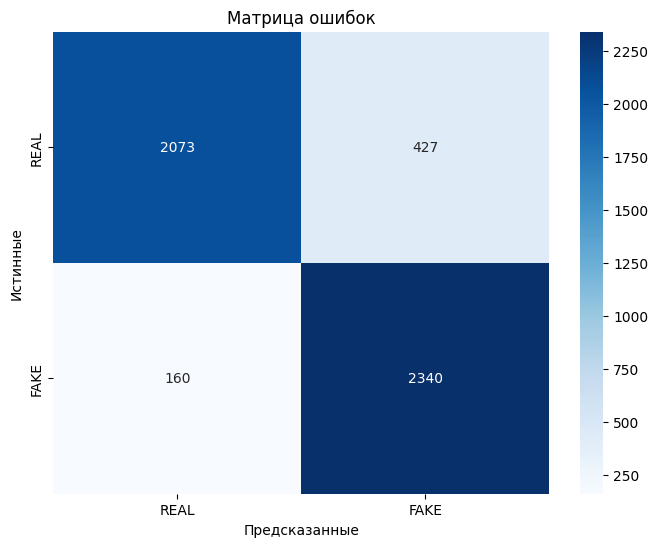

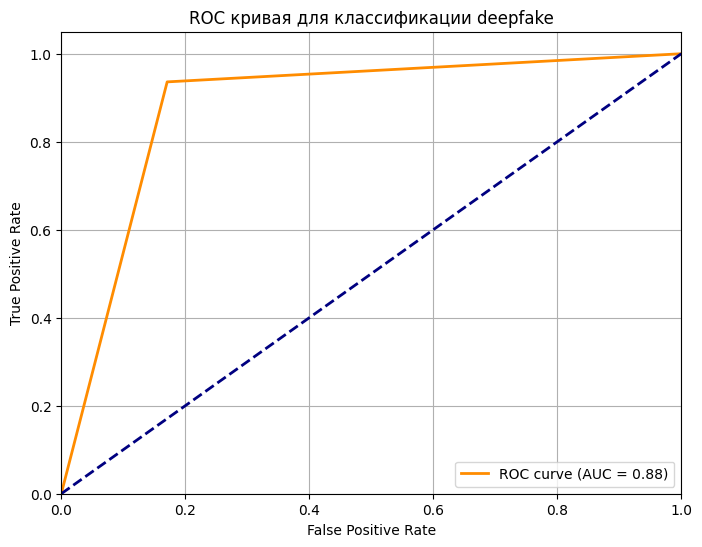

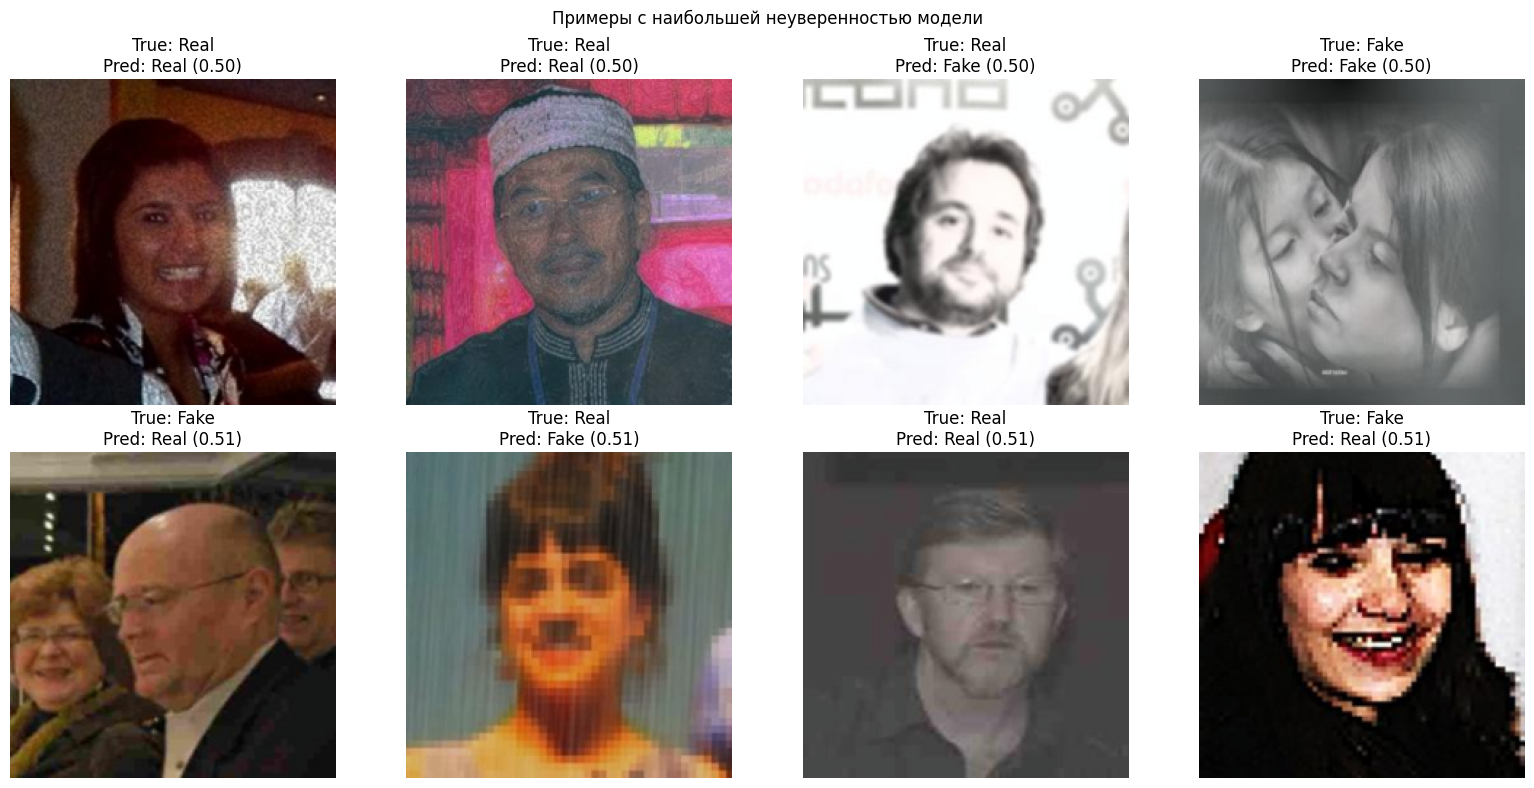


Работа завершена.


In [5]:
# main.py
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Импорты из наших модулей
from config import CONFIG, DEVICE, BATCH_SIZE, LEARNING_RATE, NUM_EPOCHS, WEIGHT_DECAY
from data_utils import load_data, create_dataloaders
from model import HybridRNNTransformerDeepfake
from train_utils import (
    EarlyStopping, train_epoch, validate_epoch,
    plot_learning_curves, evaluate_model, show_uncertain_examples
)

# Установка seed для воспроизводимости
def set_seed(seed):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

# ---------- 1. Загрузка данных ----------
print("Загрузка датасета...")
train_dataset, val_dataset, test_dataset = load_data()
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset, BATCH_SIZE
)

# ---------- 2. Создание модели ----------
print("\nСоздание модели...")
model = HybridRNNTransformerDeepfake(
    cnn_feature_dim=CONFIG['cnn_feature_dim'],
    lstm_hidden_dim=CONFIG['lstm_hidden_dim'],
    transformer_dim=CONFIG['transformer_dim'],
    num_heads=CONFIG['num_heads'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
).to(DEVICE)



# ---------- 3. Настройка обучения ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# ---------- 4. Цикл обучения ----------
print("\nНачало обучения...")
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if early_stopping(val_loss, model):
        print("Ранняя остановка активирована!")
        break

# ---------- 5. Сохранение модели и конфигурации ----------
os.makedirs("models", exist_ok=True)

# Сохраняем веса модели (лучшие, если использовалась ранняя остановка)
torch.save(model.state_dict(), "models/best_model_weights.pth")
print("\nМодель сохранена в models/best_model_weights.pth")

# Сохраняем конфигурацию в JSON
with open("models/config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)
print("Конфигурация сохранена в models/config.json")

# Сохраняем историю обучения (для дальнейшего анализа)
with open("models/history.json", "w") as f:
    json.dump(history, f, indent=4)

# ---------- 6. Визуализация кривых обучения ----------
plot_learning_curves(history)

# ---------- 7. Оценка на тесте ----------
print("\nОценка на тестовом наборе:")
test_acc, test_preds, test_labels = evaluate_model(model, test_loader, criterion, DEVICE)

# ---------- 8. Анализ неуверенных примеров ----------
show_uncertain_examples(model, test_loader, DEVICE, num_examples=8)
